In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import os 
os.chdir('')

# Overall Analysis

## POLAR result loading 

In [ ]:
# change to your own path generated from simulation.py
results = np.zeros((1102,75))
for i in range(75):
    results[:,i] = pd.read_csv('simulation/result_'+str(i).zfill(2)+'.csv').iloc[:,1:].to_numpy().reshape(1102,)

In [5]:
Q_learning_list = results[2:102, :].T.reshape(3,5,5,100)
V_function_list = results[102:, :].T.reshape(3,5,5,100,21)

In [14]:
p_list = np.array([0.95, 0.75, 0.55])
n_list = np.array([50,200,1000,5000,20000])
c_list = np.array([0,5,10,50,100])

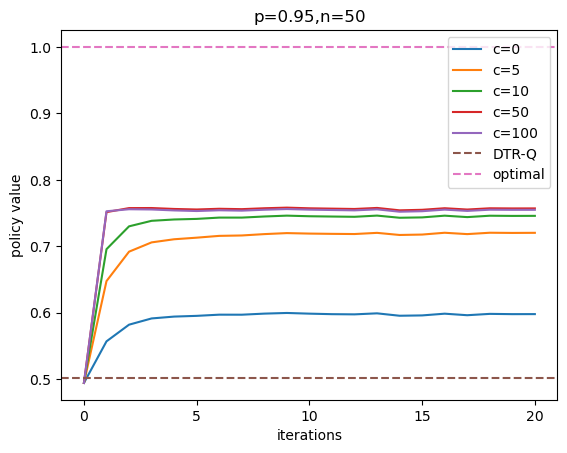

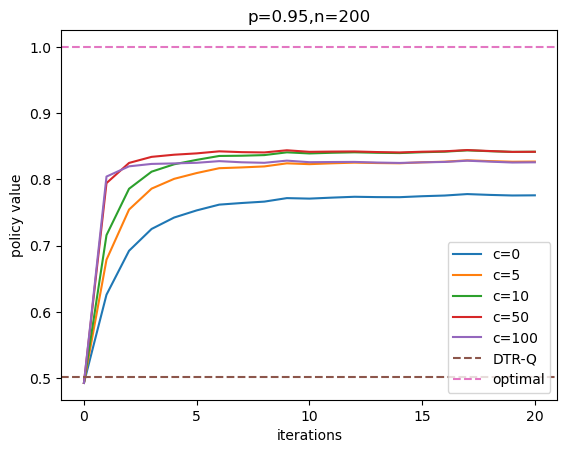

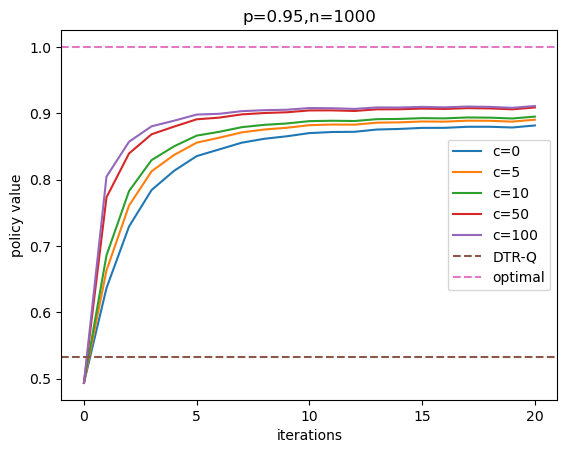

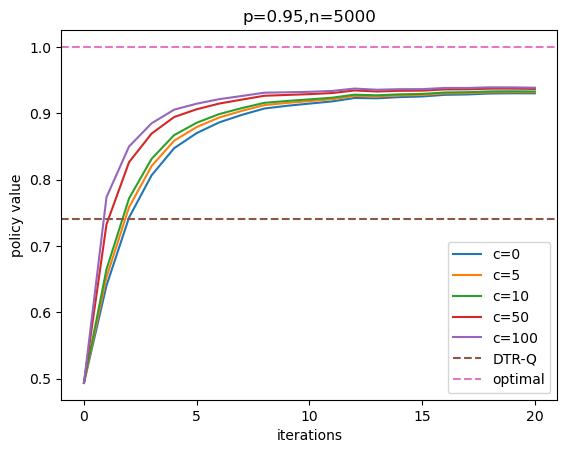

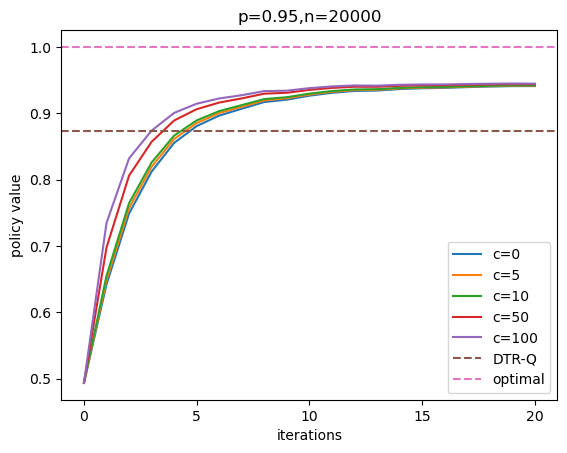

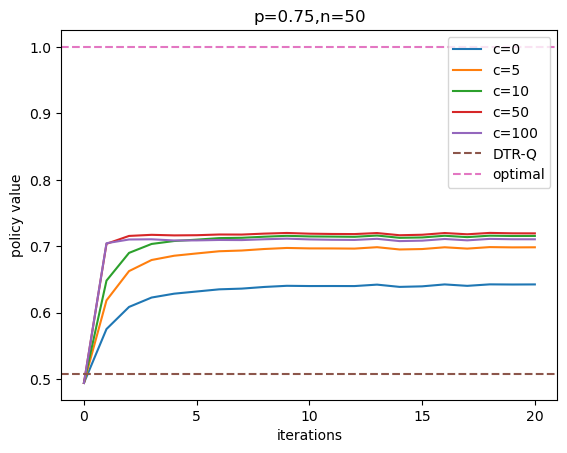

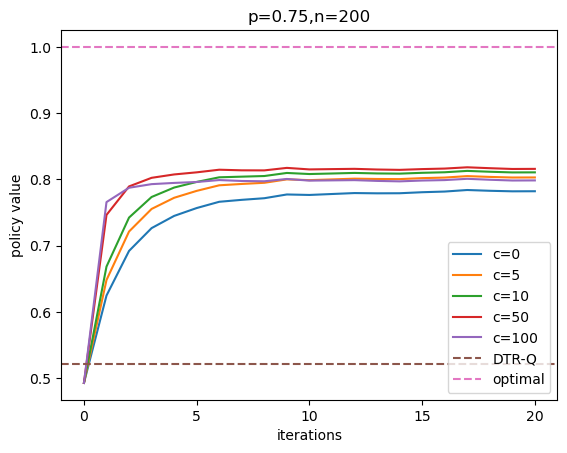

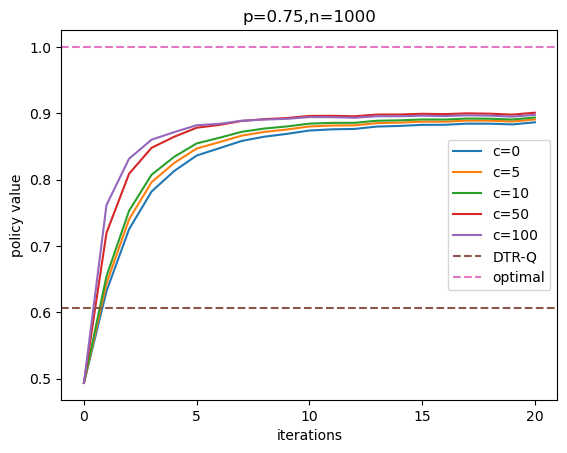

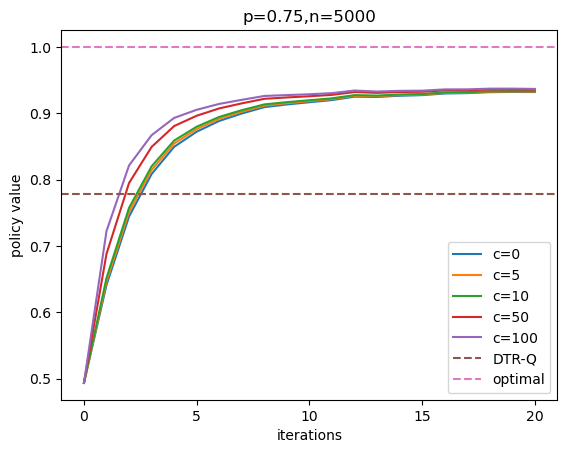

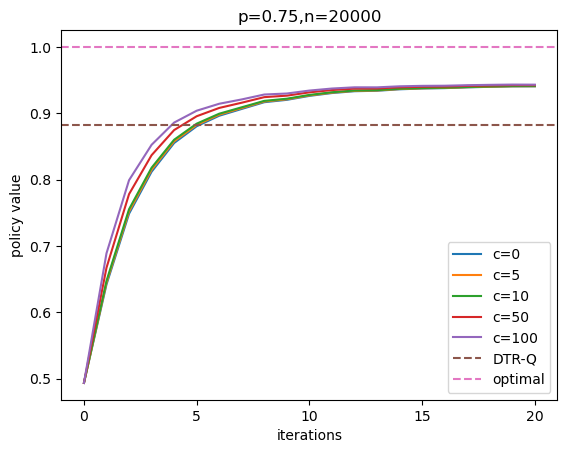

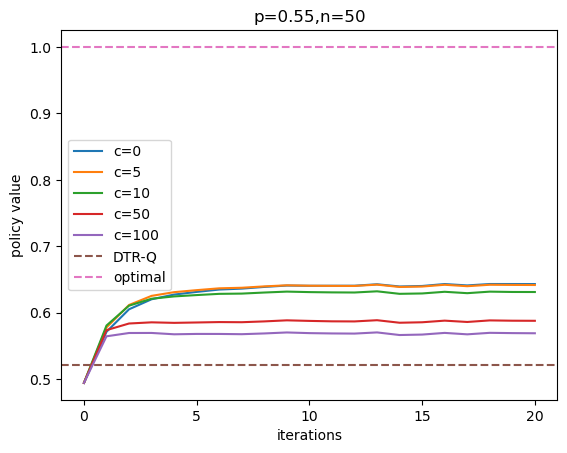

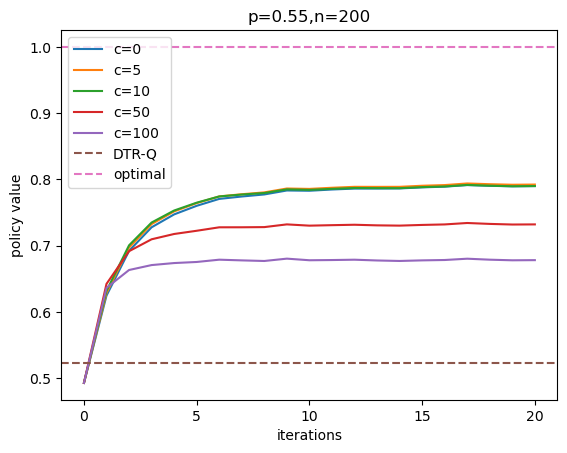

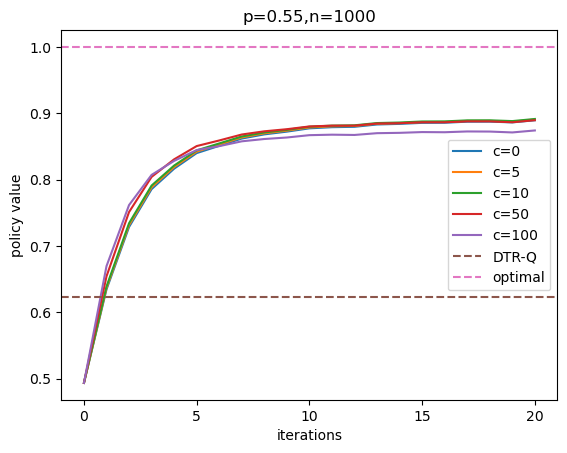

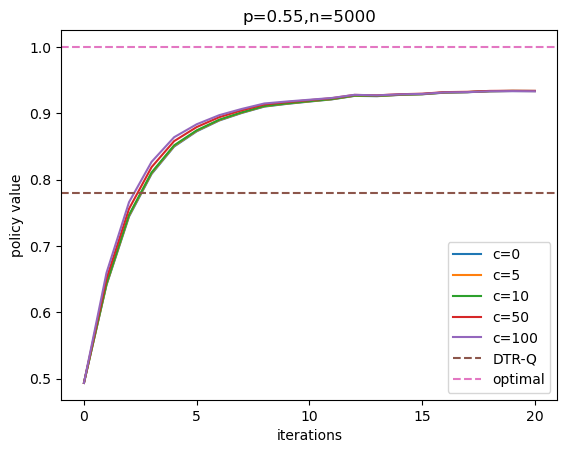

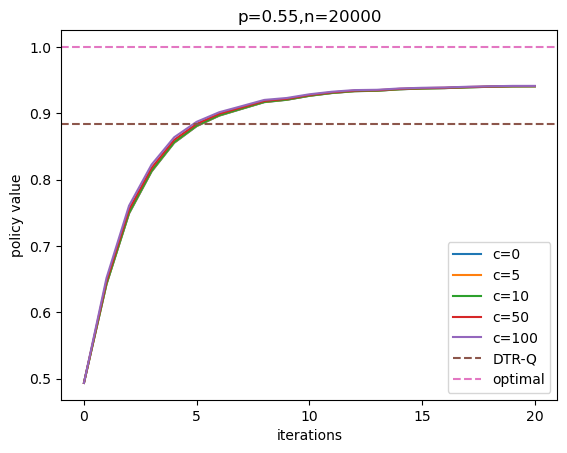

In [7]:
for jp, pp in enumerate(p_list):
    for jn, nn in enumerate(n_list):
        plt.figure(facecolor='w')
        for jc, cc in enumerate(c_list):
            plt.plot(range(21), np.mean(V_function_list[jp,jn,jc,:,:], axis=0), label = 'c={}'.format(cc))
        qlearn_average = np.mean(Q_learning_list [jp,jn,0,:])
        plt.axhline(y= qlearn_average, linestyle='--', color='tab:brown', label = 'DTR-Q')
        plt.axhline(y= 1, linestyle='--', color='tab:pink', label = 'optimal')
        plt.xlabel('iterations')
        plt.ylabel('policy value')
        plt.title('p={},n={}'.format(pp,nn))
        plt.xticks([0,5,10,15,20])
        plt.legend()

<Figure size 640x480 with 0 Axes>

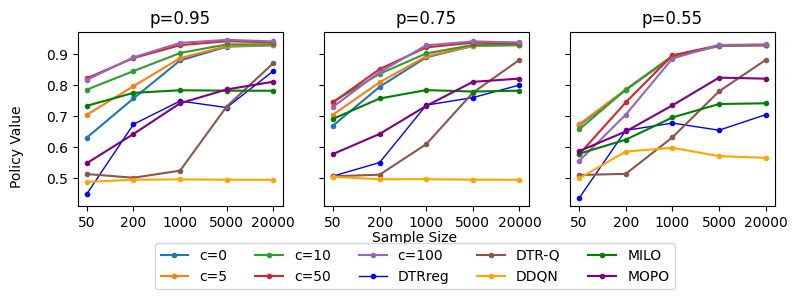

In [ ]:
plt.figure(facecolor='w')
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9, 3))

dtrreg_plotted = False
milo_plotted = False
mopo_plotted = False      # NEW FLAG

for jp, pp in enumerate(p_list):

    # Plot V-function curves for different c
    for jc, cc in enumerate(c_list):
        axs[jp].plot(
            [str(nn) for nn in n_list],
            np.mean(V_function_list[jp, :, jc, :, 11], axis=1),
            marker='.', label=f'c={cc}'
        )

    # --- DTRreg ---
    if not dtrreg_plotted:
        axs[jp].plot([str(nn) for nn in n_list], DTRreg_results[pp], 
                     marker='.', color='blue', linewidth=1, label='DTRreg')
        dtrreg_plotted = True
    else:
        axs[jp].plot([str(nn) for nn in n_list], DTRreg_results[pp], 
                     marker='.', color='blue', linewidth=1)

    # --- DTR-Q ---
    axs[jp].plot(
        [str(nn) for nn in n_list],
        np.mean(Q_learning_list[jp, :, 0, :], axis=1),
        marker='.', label='DTR-Q'
    )

    # --- DDQN ---
    axs[jp].plot(
        [str(nn) for nn in n_list],
        np.mean(DDQN_results_list[jp, :, 0, :], axis=1),
        marker='.', color='orange', label='DDQN'
    )

    # --- MILO ---
    if not milo_plotted:
        axs[jp].plot(
            [str(nn) for nn in n_list],
            np.mean(MILO_results_list[jp, :, :], axis=1),
            marker='.', color='green', label='MILO'
        )
        milo_plotted = True
    else:
        axs[jp].plot(
            [str(nn) for nn in n_list],
            np.mean(MILO_results_list[jp, :, :], axis=1),
            marker='.', color='green'
        )

    # --- MOPO (NEW) ---
    if not mopo_plotted:
        axs[jp].plot(
            [str(nn) for nn in n_list],
            np.mean(MOPO_results_list[jp, :, :], axis=1),
            marker='.', color='purple', label='MOPO'
        )
        mopo_plotted = True
    else:
        axs[jp].plot(
            [str(nn) for nn in n_list],
            np.mean(MOPO_results_list[jp, :, :], axis=1),
            marker='.', color='purple'
        )

    axs[jp].set_title(f'p={pp}')

# Common labels
fig.text(0.5, 0.18, 'Sample Size', ha='center')
fig.text(0.05, 0.5, 'Policy Value', va='center', rotation='vertical')

# Legend
handles, labels = axs[0].get_legend_handles_labels()
import math
n_cols = math.ceil(len(handles) / 2)

plt.subplots_adjust(bottom=0.3) 
fig.legend(handles, labels, ncol=n_cols, bbox_to_anchor=(0.5, 0), loc='lower center')

plt.savefig('fig', dpi=200)
plt.show()


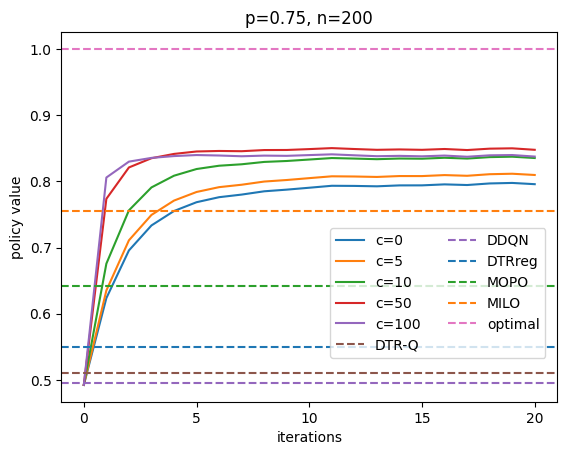

In [ ]:
jp, jn = 1,1
plt.figure(facecolor='w')
for jc, cc in enumerate(c_list):
   plt.plot(range(21), np.mean(V_function_list[jp,jn,jc,:,:], axis=0), label = 'c={}'.format(cc))

qlearn_average = np.mean(Q_learning_list[jp,jn,0,:])
plt.axhline(y=qlearn_average, linestyle='--', color='tab:brown', label='DTR-Q')

ddqn_average = np.mean(DDQN_results_list[jp,jn,0,:])
plt.axhline(y=ddqn_average, linestyle='--', color='tab:purple', label='DDQN')

dtrreg_value = 0.5494028
plt.axhline(y=dtrreg_value, linestyle='--', color='tab:blue', label='DTRreg')

mopo_value = np.mean(MOPO_results_list[jp, jn, :])
plt.axhline(y=mopo_value, linestyle='--', color='tab:green', label='MOPO')

milo_value = np.mean(MILO_results_list[jp, jn, :])
plt.axhline(y=milo_value, linestyle='--', color='tab:orange', label='MILO')

plt.axhline(y=1, linestyle='--', color='tab:pink', label='optimal')

plt.xlabel('iterations')
plt.ylabel('policy value')
plt.title('p={}, n={}'.format(p_list[jp],n_list[jn]))
plt.xticks([0,5,10,15,20])
plt.legend(ncol=2, loc='lower right', bbox_to_anchor=(0.99,0.1))
plt.savefig('', dpi=200)